# SFR Fly Mean-Reversion — 6. Fitted-curve residual

**Formulation: rich/cheap against a smooth curve through the strip.**

Each date, fit a smooth function of maturity to the 16-slot strip —
Nelson-Siegel, Svensson, a least-squares cubic spline, or a cubic polynomial —
and take each contract's deviation from it. The fly's signal is the same
weighted sum of its legs' deviations as its level is of its legs' rates.

The fit is **cross-sectional on that date only**, so it carries no time-series
look-ahead by construction — no window, no burn-in, no rolling statistic.

There is a tension worth stating up front. A butterfly is already a second
difference along the strip, and a smooth curve has small second differences by
design, so the residual of a smooth fit is *almost* the fly again. The
diagnostic below measures exactly how much: if the residual correlates ~1.0
with the raw fly, this framework is the z-score notebook with extra steps.

In [1]:
CONFIG = dict(
    primary_structure="3m",
    primary_window="liquid16",
    long_window="front8",
    cost_bp=1.5,
    n_packages=100,
    forms=("ns", "nss", "spline", "poly3"),
    z_window=120,
    entry_zs=(1.5, 2.0, 2.5),
    exits=("z0", "half", "t10"),
    directions=("fade", "momentum"),
    max_hold=30,
    lag=1,
)
CONFIG

{'primary_structure': '3m',
 'primary_window': 'liquid16',
 'long_window': 'front8',
 'cost_bp': 1.5,
 'n_packages': 100,
 'forms': ('ns', 'nss', 'spline', 'poly3'),
 'z_window': 120,
 'entry_zs': (1.5, 2.0, 2.5),
 'exits': ('z0', 'half', 't10'),
 'directions': ('fade', 'momentum'),
 'max_hold': 30,
 'lag': 1}

In [2]:
import sys
import time
from pathlib import Path

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import numpy as np
import pandas as pd

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from RVUtils.MeanRev import MRConfig
from RVUtils.MeanRev.signals import curvefit_residual_signal
from RVUtils.mean_reversion import adf_pvalue, half_life, rolling_zscore
from sfr_fly_meanrev_common import load_lab, per_slot_table, run_family

pd.set_option("display.width", 230)
pd.set_option("display.max_columns", 60)

BASE = MRConfig(lag=CONFIG["lag"], round_trip_cost_bp=CONFIG["cost_bp"],
                max_hold=CONFIG["max_hold"], n_packages=CONFIG["n_packages"])
lab = load_lab(CONFIG["primary_structure"], CONFIG["primary_window"])
levels, slot_panel, st = lab["levels"], lab["slot_panel"], lab["struct"]
print(f"{levels.shape[1]} flies, {levels.shape[0]} sessions")

34 flies, 1150 sessions


## 1. What the fits look like on one date

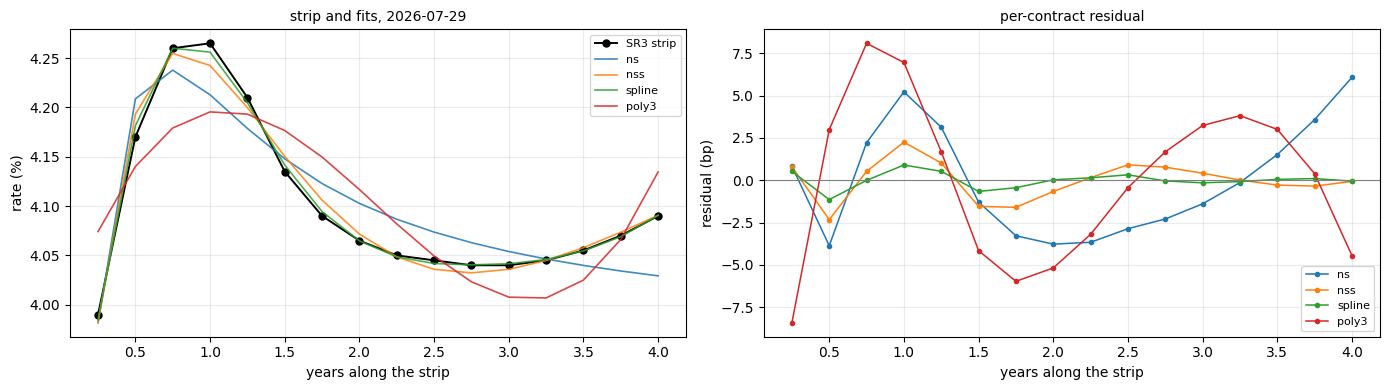

In [3]:
from RVUtils.curve_fit_rv import _ns_yield, _nss_yield
from scipy.interpolate import LSQUnivariateSpline
from scipy.optimize import least_squares

d = slot_panel.dropna().index[-1]
y = slot_panel.loc[d].dropna()
x = np.array([float(c) / 4.0 for c in y.index])
fits = {}
res = least_squares(lambda p: _ns_yield(x, *p) - y.to_numpy(),
                    [y.iloc[-1], y.iloc[0] - y.iloc[-1], 0.0, 2.0], max_nfev=800)
fits["ns"] = _ns_yield(x, *res.x)
res = least_squares(lambda p: _nss_yield(x, *p) - y.to_numpy(),
                    [y.iloc[-1], y.iloc[0] - y.iloc[-1], 0.0, 0.0, 2.0, 5.0],
                    max_nfev=800)
fits["nss"] = _nss_yield(x, *res.x)
fits["spline"] = LSQUnivariateSpline(x, y.to_numpy(),
                                     t=np.quantile(x, [0.33, 0.66]), k=3)(x)
fits["poly3"] = np.polyval(np.polyfit(x, y.to_numpy(), 3), x)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(x, y.to_numpy(), "o-", color="black", lw=1.4, ms=5, label="SR3 strip")
for k, v in fits.items():
    axes[0].plot(x, v, lw=1.2, alpha=0.85, label=k)
axes[0].set_xlabel("years along the strip")
axes[0].set_ylabel("rate (%)")
axes[0].set_title(f"strip and fits, {pd.Timestamp(d).date()}", fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)
for k, v in fits.items():
    axes[1].plot(x, (y.to_numpy() - v) * 100, "o-", lw=1.1, ms=3, label=k)
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].set_xlabel("years along the strip")
axes[1].set_ylabel("residual (bp)")
axes[1].set_title("per-contract residual", fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 2. Is the residual anything other than the fly?

The residual panels are memoised per `(form, panel)`: the diagnostic below, the
grid, and the raw-bp variant all want the same four panels, and each one is
~1,150 non-linear curve fits. Without the cache the notebook recomputes them
about ten times over.

In [4]:
_RESID_CACHE = {}


def resid_panel(sp, struct, form, tag):
    k = (tag, form)
    if k not in _RESID_CACHE:
        _RESID_CACHE[k] = curvefit_residual_signal(sp, struct, form=form)
    return _RESID_CACHE[k]


rows = []
for form in CONFIG["forms"]:
    t0 = time.time()
    r = resid_panel(slot_panel, st, form, "primary")
    r = r.reindex(index=levels.index, columns=levels.columns)
    dt = time.time() - t0
    cors, sds, hls, adfs = [], [], [], []
    for c in r.columns:
        s = r[c].dropna()
        if len(s) < 250:
            continue
        cors.append(float(levels[c].corr(r[c])))
        sds.append(float(s.std()))
        hls.append(half_life(s))
        adfs.append(adf_pvalue(s))
    rows.append({"form": form, "seconds": dt, "n_keys": len(cors),
                 "median_corr_with_fly": np.nanmedian(cors),
                 "median_sd_bp": np.nanmedian(sds),
                 "median_hl": np.nanmedian(hls),
                 "pct_stationary": float(np.mean(np.array(adfs) < 0.10))})
diag = pd.DataFrame(rows)
print(diag.round(3).to_string(index=False))
print("\n  median_corr_with_fly near 1.0 means the 'curve residual' IS the fly, "
      "and this framework collapses into the z-score notebook.")

  form  seconds  n_keys  median_corr_with_fly  median_sd_bp  median_hl  pct_stationary
    ns    2.495      24                 0.727         2.554     24.112           0.125
   nss   64.491      24                 0.681         2.509     19.845           0.292
spline    0.115      24                 0.373         1.647     10.510           0.542
 poly3    0.058      24                 0.793         3.145     25.214           0.208

  median_corr_with_fly near 1.0 means the 'curve residual' IS the fly, and this framework collapses into the z-score notebook.


## 3. Backtest


### GRID  (34 keys, 1150 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/72 configs


  50/72 configs


  72 configs | median -491.00bp | IQR [-709.75, -342.25] | 0% net-positive | best -122.00bp

  top rows (SELECTION-INFLATED - read the distribution above first):
  form  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    ns      2.5         z0      fade       173     0.173      -0.705       -122.00      -305000.0  -0.799    -203.25
   nss      2.5         z0      fade       167     0.186      -0.820       -137.00      -342500.0  -0.899    -199.75
   nss      2.5       half      fade       177     0.181      -0.845       -149.50      -373750.0  -1.031    -191.50
    ns      2.5       half      fade       184     0.174      -0.827       -152.25      -380625.0  -1.053    -214.50
spline      2.5         z0      fade       182     0.187      -0.868       -158.00      -395000.0  -1.070    -190.00
 poly3      2.5       half      fade       154     0.169      -1.226       -188.75      -471875.0  -1.317    -189.25
spline      2.5    

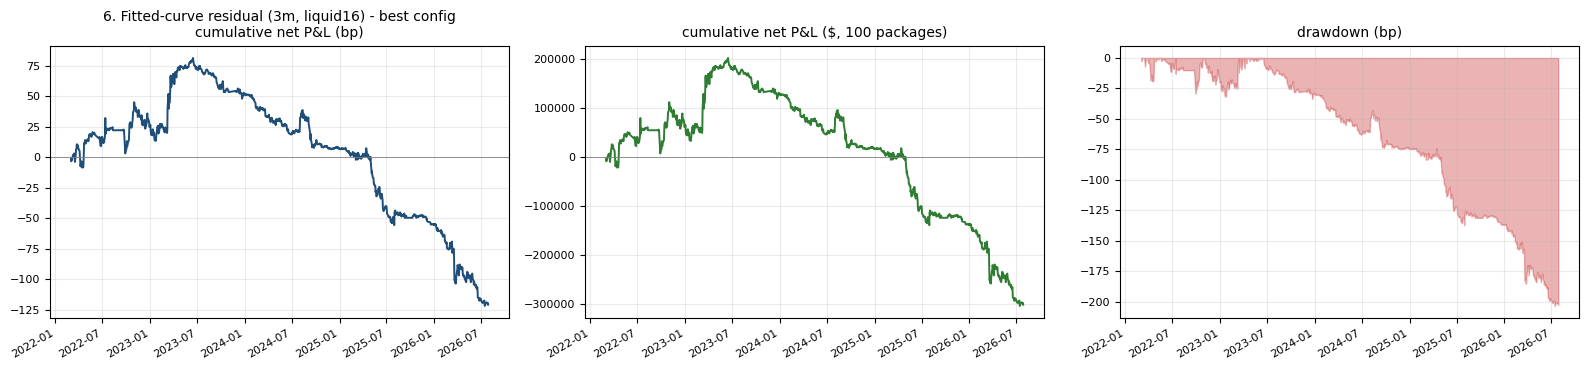


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
Z23-H24-M24    1  2022-03-01 2022-03-02 2022-04-13    30 -3.825     -2.00       -5.0     -3.00      1.5   -4.50 -11250.0       max_hold
U23-Z23-H24   -1  2022-03-01 2022-03-02 2022-03-14     8  3.108      6.50        5.0      1.50      1.5    0.00      0.0 mean_reversion
H24-M24-U24    1  2022-03-02 2022-03-03 2022-03-31    20 -2.699     -4.00       -2.0      2.00      1.5    0.50   1250.0 mean_reversion
U22-Z22-H23   -1  2022-03-03 2022-03-04 2022-04-18    30  2.505      5.00        9.5     -4.50      1.5   -6.00 -15000.0       max_hold
Z24-H25-M25    1  2022-03-04 2022-03-07 2022-03-16     7 -2.679     -3.00       -1.5      1.50      1.5    0.00      0.0 mean_reversion
M23-U23-Z23   -1  2022-03-15 2022-03-16 2022-04-28    30  3.017      6.50        9.0     -2.50      1.5   -4.00 -10000.0       max_hold
H25-M25-U25    1  202

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       173    21.237     0.173      -0.705       -122.00  -0.799
half       184    17.690     0.174      -0.827       -152.25  -1.053
band       184    17.690     0.174      -0.827       -152.25  -1.053
  t5       307     4.980     0.127      -1.366       -419.25  -4.418
 t10       240     9.875     0.125      -1.268       -304.25  -2.578
 t20       179    19.603     0.162      -1.172       -209.75  -1.455

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 173         137.5       0.795     0.526       343750.0
           0.5 173          51.0       0.295     0.329       127500.0
           1.0 173         -35.5      -0.205     0.225       -88750.0
           1.5 173        -122.0      -0.705     0.173      -305000.0
           2.5 173        -295.0      -1.705     0.127      -737500.0
           4.0 173        -554.5      -3.20


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5       173           137.5        -122.0      -0.705     0.173  -0.799     -203.3      21.2          False             False
         belly       1            0.5       173           523.5         437.0       2.526     0.526   0.537     -234.5      21.2           True              True
belly_vs_front       2            1.0       173           -54.5        -227.5      -1.315     0.318  -1.091     -233.0      21.2          False             False
 belly_vs_back       2            1.0       173           192.0          19.0       0.110     0.358   0.123      -93.5      21.2           True              True
  -> SHADOWED - a simpler instrument beats the fly on net bp
6. Fitted-curve residual (3m, liquid16) - MEDIAN config 

In [5]:
def cf_sig(L, form):
    r = resid_panel(slot_panel, st, form, "primary")
    r = r.reindex(index=L.index, columns=L.columns)
    return r.apply(lambda s: rolling_zscore(s, CONFIG["z_window"],
                                            min_periods=40, ddof=0))


GRID = {"form": CONFIG["forms"], "entry_z": CONFIG["entry_zs"],
        "exit_style": CONFIG["exits"], "direction": CONFIG["directions"]}
PARAMS = ["form", "entry_z", "exit_style", "direction"]
out = run_family("6. Fitted-curve residual (3m, liquid16)", lab=lab,
                 signal_fn=cf_sig, grid_spec=GRID, params=PARAMS, base=BASE,
                 cls="curvefit", note="NS / NSS / spline / cubic, z-scored")

## 4. Raw residual in bp, no second standardisation


### GRID  (34 keys, 1150 sessions, window=liquid16: every strip slot trades every session from 2022)


  24 configs | median -565.75bp | IQR [-956.31, -323.94] | 4% net-positive | best +18.25bp

  top rows (SELECTION-INFLATED - read the distribution above first):
  form  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
spline      4.0         z0      fade       102     0.461       0.179         18.25        45625.0   0.129     -73.75
   nss      4.0         z0      fade       137     0.387      -0.485        -66.50      -166250.0  -0.242    -179.75
spline      2.0         z0      fade       243     0.366      -0.328        -79.75      -199375.0  -0.403    -154.00
spline      4.0        t10      fade       182     0.330      -0.988       -179.75      -449375.0  -1.364    -199.25
   nss      2.0         z0      fade       300     0.280      -0.902       -270.50      -676250.0  -0.892    -333.25
   nss      4.0        t10      fade       291     0.258      -1.110       -323.00      -807500.0  -1.329    -397.75
spline      4.0     

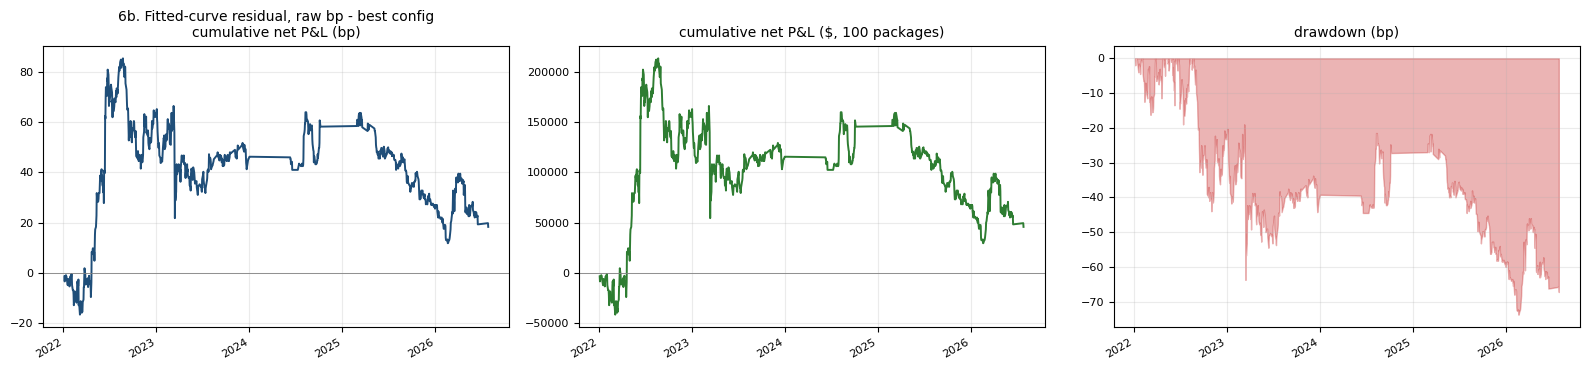


  trade log (first rows):
        key  dir signal_date      entry       exit  days    z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
H22-M22-U22   -1  2022-01-03 2022-01-04 2022-02-16    30   4.116      3.00      15.75    -12.75      1.5  -14.25 -35625.0       max_hold
U22-Z22-H23    1  2022-01-14 2022-01-18 2022-03-02    30  -4.311     -2.00       4.50      6.50      1.5    5.00  12500.0       max_hold
H22-M22-U22   -1  2022-02-17 2022-02-18 2022-03-15    16   5.515     15.00      20.00     -5.00      1.5   -6.50 -16250.0       max_hold
U24-Z24-H25   -1  2022-02-28 2022-03-01 2022-04-12    30   4.131      2.50       3.00     -0.50      1.5   -2.00  -5000.0       max_hold
U23-Z23-H24   -1  2022-03-01 2022-03-02 2022-03-28    18   5.109      6.50       2.50      4.00      1.5    2.50   6250.0 mean_reversion
Z23-H24-M24    1  2022-03-04 2022-03-07 2022-04-19    30  -4.082     -2.00      -5.00     -3.00      1.5   -4.50 -11250.0       max_hold
U22-Z22-H23   


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5       102           171.2          18.2       0.179     0.461   0.129      -73.8      22.3          False             False
         belly       1            0.5       102           175.0         124.0       1.216     0.480   0.263     -158.5      22.3           True              True
belly_vs_front       2            1.0       102           102.8           0.8       0.007     0.471   0.004     -150.0      22.3          False             False
 belly_vs_back       2            1.0       102            68.5         -33.5      -0.328     0.461  -0.236      -80.5      22.3          False             False
  -> SHADOWED - a simpler instrument beats the fly on net bp
6b. Fitted-curve residual, raw bp - MEDIAN config (the a

In [6]:
def cf_raw(L, form):
    r = resid_panel(slot_panel, st, form, "primary")
    return r.reindex(index=L.index, columns=L.columns)


out_raw = run_family(
    "6b. Fitted-curve residual, raw bp", lab=lab, signal_fn=cf_raw,
    grid_spec={"form": ("nss", "spline"), "entry_z": (1.0, 2.0, 4.0),
               "exit_style": ("z0", "t10"), "direction": ("fade", "momentum")},
    params=["form", "entry_z", "exit_style", "direction"],
    base=BASE, cls="curvefit", note="entry threshold in bp of residual")

## 5. Per-slot and long window

In [7]:
per = per_slot_table(out["result"], lab)
if not per.empty:
    print(per.round(3).to_string(index=False))

 slot           cm  n   hit  avg_net_bp  total_net_bp  total_gross_bp  avg_hold  total_net_usd
  2.0       SFR123 22 0.364       1.182          26.0            59.0    21.000        65000.0
  3.0       SFR234 14 0.286      -0.393          -5.5            15.5    23.786       -13750.0
  4.0       SFR345  9 0.333      -1.389         -12.5             1.0    21.444       -31250.0
  5.0       SFR456 13 0.077      -1.538         -20.0            -0.5    28.308       -50000.0
  6.0       SFR567 16 0.312      -0.406          -6.5            17.5    26.250       -16250.0
  7.0       SFR678  5 0.000      -1.200          -6.0             1.5    27.600       -15000.0
  8.0       SFR789 14 0.143      -0.929         -13.0             8.0    23.643       -32500.0
  9.0   SFR-8-9-10 17 0.118      -1.029         -17.5             8.0    22.353       -43750.0
 10.0  SFR-9-10-11  9 0.222      -0.778          -7.0             6.5    19.222       -17500.0
 11.0 SFR-10-11-12 13 0.000      -1.500         -1


### GRID  (42 keys, 1907 sessions, window=front8: slots 1-8 are continuously liquid from 2019; buys ZIRP+hiking)


  25/36 configs


  36 configs | median -427.12bp | IQR [-573.69, -230.06] | 0% net-positive | best -65.00bp

  top rows (SELECTION-INFLATED - read the distribution above first):
  form  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
spline      2.5         z0      fade       142     0.282      -0.458        -65.00      -162500.0  -0.381     -99.50
   nss      2.5       half      fade       144     0.299      -0.540        -77.75      -194375.0  -0.476    -102.00
   nss      2.5         z0      fade       141     0.312      -0.566        -79.75      -199375.0  -0.459     -96.50
spline      2.5        t10      fade       185     0.259      -0.672       -124.25      -310625.0  -0.779    -144.75
spline      2.5       half      fade       150     0.247      -0.938       -140.75      -351875.0  -0.885    -145.75
spline      2.0         z0      fade       235     0.285      -0.626       -147.00      -367500.0  -0.677    -154.25
   nss      2.5     

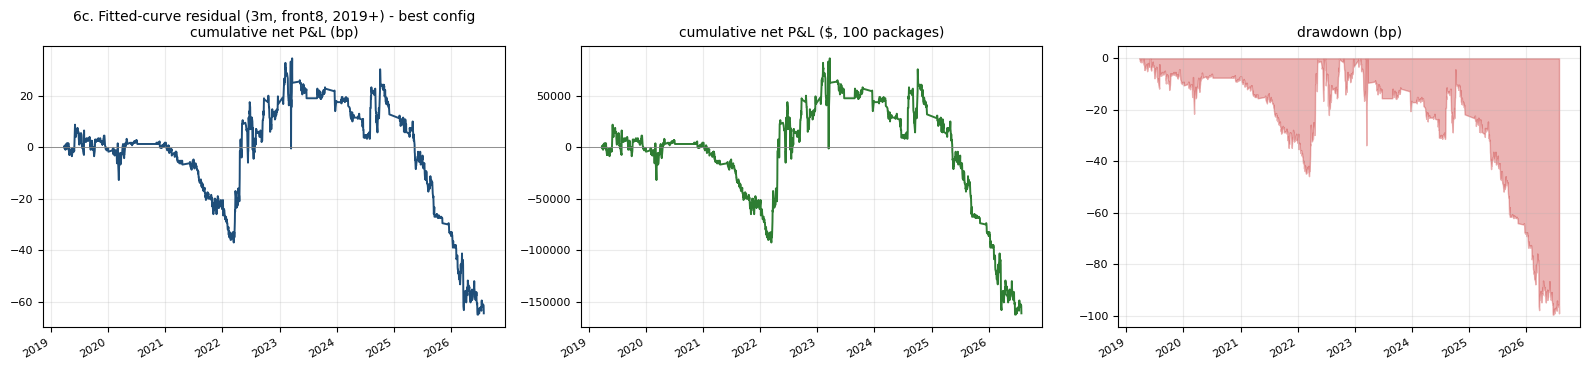


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
M19-U19-Z19    1  2019-03-25 2019-03-26 2019-04-08     9 -3.186      0.50       2.50      2.00      1.5    0.50   1250.0 mean_reversion
M20-U20-Z20   -1  2019-03-27 2019-03-28 2019-04-29    21  2.715     -3.50      -2.50     -1.00      1.5   -2.50  -6250.0 mean_reversion
Z19-H20-M20   -1  2019-04-01 2019-04-02 2019-05-15    30  2.643     -0.50      -2.50      2.00      1.5    0.50   1250.0 mean_reversion
U19-Z19-H20    1  2019-04-01 2019-04-02 2019-05-15    30 -3.395     -1.00      -2.00     -1.00      1.5   -2.50  -6250.0       max_hold
M19-U19-Z19    1  2019-04-22 2019-04-23 2019-05-09    12 -2.546      0.50       2.50      2.00      1.5    0.50   1250.0 mean_reversion
M19-U19-Z19   -1  2019-05-21 2019-05-22 2019-06-05     9  2.911      4.25      -8.25     12.50      1.5   11.00  27500.0 mean_reversion
H20-M20-U20   -1  201

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       142    19.373     0.282      -0.458        -65.00  -0.381
half       150    15.907     0.247      -0.938       -140.75  -0.885
band       150    15.907     0.247      -0.938       -140.75  -0.885
  t5       247     4.935     0.142      -1.280       -316.25  -3.188
 t10       185     9.724     0.259      -0.672       -124.25  -0.779
 t20       149    19.221     0.248      -0.517        -77.00  -0.421

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 142         148.0       1.042     0.549       370000.0
           0.5 142          77.0       0.542     0.479       192500.0
           1.0 142           6.0       0.042     0.366        15000.0
           1.5 142         -65.0      -0.458     0.282      -162500.0
           2.5 142        -207.0      -1.458     0.225      -517500.0
           4.0 142        -420.0      -2.95


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5       142           148.0         -65.0      -0.458     0.282  -0.381      -99.5      19.4          False             False
         belly       1            0.5       142           -66.0        -137.0      -0.965     0.465  -0.230     -240.5      19.4          False              True
belly_vs_front       2            1.0       142           144.5           2.5       0.018     0.373   0.013     -135.0      19.4           True              True
 belly_vs_back       2            1.0       142             3.5        -138.5      -0.975     0.394  -0.956     -157.0      19.4          False             False
  -> SHADOWED - a simpler instrument beats the fly on net bp
6c. Fitted-curve residual (3m, front8, 2019+) - MEDIAN c

In [8]:
lab8 = load_lab(CONFIG["primary_structure"], CONFIG["long_window"])
st8, sp8 = lab8["struct"], lab8["slot_panel"]


def cf_sig8(L, form):
    r = resid_panel(sp8, st8, form, "front8")
    r = r.reindex(index=L.index, columns=L.columns)
    return r.apply(lambda s: rolling_zscore(s, CONFIG["z_window"],
                                            min_periods=40, ddof=0))


out8 = run_family("6c. Fitted-curve residual (3m, front8, 2019+)", lab=lab8,
                  signal_fn=cf_sig8,
                  grid_spec={"form": ("nss", "spline"),
                             "entry_z": CONFIG["entry_zs"],
                             "exit_style": CONFIG["exits"],
                             "direction": CONFIG["directions"]},
                  params=PARAMS, base=BASE, cls="curvefit", note="long history")